# LangChain Ecosystem

## 1. LangChain

**LangChain** is a framework used to build applications powered by Large Language Models (LLMs).

It helps connect:

* LLMs (GPT, Gemini, Groq, etc.)
* Tools
* Databases
* APIs
* Memory

### Example Uses

* Chatbots
* RAG Applications
* AI Assistants
* Q&A Systems

**Think of LangChain as the toolkit for building AI applications.**

---

## 2. LangGraph

**LangGraph** is built on top of LangChain and is used to create AI agents using graphs and workflows.

It allows:

* Multiple steps
* Decision making
* Loops
* Agent workflows
* Multi-agent systems

### Example Uses

* AI Agents
* Tool-calling agents
* Research agents
* Multi-step reasoning systems

**Think of LangGraph as a flowchart for AI agents.**

---

## 3. LangSmith

**LangSmith** is a monitoring and debugging platform for LangChain and LangGraph applications.

It helps:

* Track executions
* Debug errors
* View agent steps
* Evaluate performance
* Monitor production applications

### Example Uses

* Debugging agents
* Viewing tool calls
* Monitoring LLM responses
* Performance analysis

**Think of LangSmith as the dashboard for observing and debugging your AI application.**

---

# Quick Summary

| Tool      | Purpose                                      |
| --------- | -------------------------------------------- |
| LangChain | Build LLM applications                       |
| LangGraph | Build AI agents and workflows                |
| LangSmith | Debug, monitor, and evaluate AI applications |

### Easy Analogy

* **LangChain** → Engine
* **LangGraph** → GPS / Route Planner
* **LangSmith** → Dashboard & Diagnostics

Together, they help you build, run, and monitor AI applications.


### Summary
- Graph = Nodes + connections (flowchart).
- Workflow = Sequence of steps to complete a task.
- LangChain Agent = Quick and easy tool-calling agent.
- LangGraph = Better control for complex agents, loops, routing, and multi-agent systems.
- Functional API = Define behavior using functions.
- Graph API = Explicitly build a flowchart using nodes and edges.

Interview Answer
LangChain agents are great for simple tool-calling workflows. LangGraph is useful when we need complex workflows involving multiple steps, loops, conditional routing, or multiple agents.

# Building a basic chat bot with Langgraph (using Graph API)


there is one more API called Functional API. But initially Graph API is suggested

In [19]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START,END,StateGraph
from langgraph.graph.message import add_messages

# LangGraph Basics (Simple Notes)

## Imports

```python
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
```

### What do they do?

### TypedDict

Used to define the structure of the data (state) that flows through the graph.

```python
class State(TypedDict):
    messages: list
```

Think of it as a dictionary with fixed keys.

---

### Annotated

Adds extra instructions to a field.

```python
messages: Annotated[list, add_messages]
```

Meaning:

> When new messages come, append them instead of replacing the old ones.

---

### add_messages

Maintains chat history.

Without it:

```python
["Hello"]
```

becomes

```python
["How are you?"]
```

With it:

```python
["Hello", "How are you?"]
```

---

### StateGraph

Creates the workflow (graph).

```python
graph = StateGraph(State)
```

Think of it as a flowchart.

---

### START

Special node where execution begins.

```text
START
  |
  v
```

---

### END

Special node where execution stops.

```text
  |
  v
 END
```

---

## Overall Flow

```text
User Input
    |
    v
  START
    |
    v
 chatbot
    |
    v
   END
```

### Easy Analogy

* **State** → Notebook carrying data
* **StateGraph** → Flowchart
* **START** → Starting point
* **END** → Ending point
* **messages** → Conversation history
* **add_messages** → Keep adding new messages instead of deleting old ones


In [20]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)
# This line creates a new LangGraph workflow (graph) and tells it:
# "The data flowing through this graph will follow the structure defined in State."
# So LangGraph now knows that every node will receive and return a state containing a messages field.


In [21]:
graph_builder

In [22]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [23]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={}, client=<groq.resources.chat.completions.Completions object at 0x10a926750>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ae01a10>, model_name='groq:qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [24]:
llm=init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10ae28210>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ae290d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [25]:
# Node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

# This node takes the chat history, sends it to the LLM, gets the 
# AI response, and adds that response back to the conversation history.

In [27]:
graph_builder=StateGraph(State)

#Adding node
graph_builder.add_node("llm_chatbot",chatbot)

#Adding edge
graph_builder.add_edge(START,"llm_chatbot")
graph_builder.add_edge("llm_chatbot",END)

#Compile the graph
graph=graph_builder.compile()

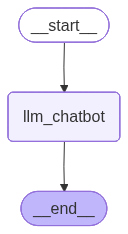

In [28]:
# Visualise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [29]:
response=graph.invoke({"messages":"Hi"})

response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='1b01fa5d-517e-4db4-acdd-855089973e98'),
  AIMessage(content='<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like, "Hello! How can I assist you today?" That sounds good. It\'s open-ended and invites them to ask questions or share what they need help with. I should keep the tone positive and approachable. No need for any markdown, just a simple, clear response.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 9, 'total_tokens': 119, 'completion_time': 0.19948236, 'completion_tokens_details': None, 'prompt_time': 0.000412824, 'prompt_tokens_details': None, 'queue_time': 0.342609545, 'total_time': 0.199895184}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprin

In [32]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='1b01fa5d-517e-4db4-acdd-855089973e98'),
 AIMessage(content='<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like, "Hello! How can I assist you today?" That sounds good. It\'s open-ended and invites them to ask questions or share what they need help with. I should keep the tone positive and approachable. No need for any markdown, just a simple, clear response.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 9, 'total_tokens': 119, 'completion_time': 0.19948236, 'completion_tokens_details': None, 'prompt_time': 0.000412824, 'prompt_tokens_details': None, 'queue_time': 0.342609545, 'total_time': 0.199895184}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe

In [33]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like, "Hello! How can I assist you today?" That sounds good. It\'s open-ended and invites them to ask questions or share what they need help with. I should keep the tone positive and approachable. No need for any markdown, just a simple, clear response.\n</think>\n\nHello! How can I assist you today? 😊'

# Understanding the Chatbot Node in LangGraph

## Chatbot Node

```python
def chatbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }
```

---

## What does this function do?

This function acts as a **node** in the LangGraph workflow.

Its job is to:

1. Read the current conversation history.
2. Send it to the LLM.
3. Get the AI response.
4. Return the response as a new message.

---

## Step 1: Receive the Current State

```python
state
```

Example:

```python
{
    "messages": [
        HumanMessage("Hi")
    ]
}
```

The state contains the conversation history.

---

## Step 2: Access Messages

```python
state["messages"]
```

Output:

```python
[
    HumanMessage("Hi")
]
```

This is the chat history that will be sent to the model.

---

## Step 3: Call the LLM

```python
llm.invoke(state["messages"])
```

The LLM processes the conversation and generates a response.

Example:

```python
AIMessage("Hello! How can I help?")
```

---

## Step 4: Return the Response

```python
return {
    "messages": [
        llm.invoke(state["messages"])
    ]
}
```

Example:

```python
{
    "messages": [
        AIMessage("Hello! How can I help?")
    ]
}
```

---

## What Happens Next?

Since our state is defined as:

```python
class State(TypedDict):
    messages: Annotated[list, add_messages]
```

LangGraph uses `add_messages` to append the new AI message instead of replacing the old messages.

---

## Before Execution

```python
{
    "messages": [
        HumanMessage("Hi")
    ]
}
```

---

## Node Output

```python
{
    "messages": [
        AIMessage("Hello! How can I help?")
    ]
}
```

---

## Final State After Merging

```python
{
    "messages": [
        HumanMessage("Hi"),
        AIMessage("Hello! How can I help?")
    ]
}
```

The conversation history is preserved.

---

## Flow Diagram

```text
User Message
      |
      v
state["messages"]
      |
      v
llm.invoke(...)
      |
      v
AI Response
      |
      v
Return {"messages": [...]}
      |
      v
add_messages appends response
```

---

## One-Line Summary

The chatbot node takes the current conversation history, sends it to the LLM, gets the AI response, and adds that response back to the conversation history.


In [34]:
# calling chat bot without invoke
for event in graph.stream({"messages":"Hi,how are you?"}):
    print(event) #prints AI messages

{'llm_chatbot': {'messages': [AIMessage(content="<think>\nLet me consider how to respond to this casual greeting. The user is likely looking for a friendly and open conversation. I should acknowledge their greeting in a warm and welcoming way. \n\nI notice they've used a casual tone, so I'll match that with a similarly friendly response. Since they haven't mentioned anything specific about their day or current situation, I can keep it general but still show genuine interest in connecting.\n\nI want to make sure my response is both welcoming and encourages further conversation. They might be looking to chat or have a specific question, so I'll include an offer to help while keeping it open-ended.\n\nI should keep it simple and natural-sounding. No need for overly formal language here. Just a straightforward, cheerful response that shows I'm here and ready to engage.\n\nThe response should be in a friendly tone, perhaps with an emoji to make it more approachable. I'll make sure it's conc

In [35]:
for event in graph.stream({"messages":"Hi,how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)


<think>
Hmm, the user greeted me with a friendly 'Hi, how are you?' and I should respond in kind. I need to make sure my reply is both warm and professional, while keeping the conversation light and engaging. Let me think about the best way to acknowledge their greeting.

First, I should greet them back and express that I'm doing well. Then, I can invite them to share how they're feeling or what's on their mind. This approach encourages further interaction and shows I'm genuinely interested in their thoughts.

I should also keep the tone positive and approachable, maybe add a little smiley to convey warmth. Let me put that all together in a natural, conversational way without any markdown formatting.
</think>

Hello! I'm doing great, thank you for asking. I'm always excited to learn and chat with users like you. How are you feeling today? I'd love to hear what's on your mind! 😊


### Chatbot with tools

In [36]:
from langchain_tavily import TavilySearch # tavily is like a search engine for agents

tool=TavilySearch(max_results=2)
tool.invoke("WHat is Tavily?")

{'query': 'WHat is Tavily?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://ai-sdk.dev/resources/tools/tavily',
   'title': 'Tavily - AI SDK',
   'content': "Tavily is a web intelligence platform offering real-time web search optimized for AI applications. Tavily provides comprehensive web research capabilities including search, content extraction, website crawling, and site mapping to power AI agents with current information. ## Installation. pnpm add @tavily/ai-sdk`. ## API Key. # Add to your .env file. ## Usage. import { generateText, stepCountIs } from 'ai';. import { tavilySearch } from '@tavily/ai-sdk';. model: 'google/gemini-3-pro-preview',. prompt: 'What are the latest developments in agentic search?',. ## Get Started. ## Build. ## Secure. ## Resources. ## Frameworks. ## SDKs. ## Use Cases. ## Company. ## Community.",
   'score': 0.9035075,
   'raw_content': None},
  {'url': 'https://learn.microsoft.com/en-us/connectors/tavily',
   '

In [37]:
# custom function
def multiply(a:int,b:int)->int:
    """
    Multiply a and b

    Args:
    a (int):first int
    b (int):second int

    Returns:
    int: output int
    """
    return a*b



ensure there is a space b/w a and (int), inside docstring. Otherwise it will show the error:Arg a(int) in docstring not found in function signature.

In [38]:
tools=[tool,multiply]

In [39]:
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x10ae28210>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ae290d0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurat

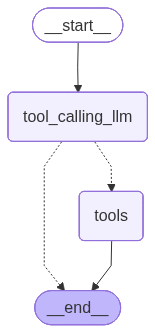

In [40]:
# Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -› tools_condition routes to tools 
    # If the latest message (result) from assistant is a not a tool call -› tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

#compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
response=graph.invoke({"messages":"Whats he latest fiancial news"})
response
#here you will se content in the AIMessage as 0 b/c here AI used tool 

{'messages': [HumanMessage(content='Whats he latest fiancial news', additional_kwargs={}, response_metadata={}, id='7900af75-1e42-42b7-aeba-63d24ca30ecd'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, let\'s tackle the user\'s query: "Whats he latest fiancial news". First, I notice there\'s a typo in "fiancial" which should be "financial". But the main goal is to find the latest financial news.\n\nLooking at the available tools, the user provided two functions: tavily_search and multiply. Since the user is asking for news, the multiply function isn\'t relevant here. So, I should use tavily_search.\n\nNext, I need to structure the parameters for tavily_search. The query parameter is essential, so I\'ll set that to "latest financial news". The user mentioned "latest", which suggests they want recent information. The topic parameter in the tool allows specifying "general", "news", or "finance". Since financial news is a subset of the "finance" topic, I should set

In [42]:
response["messages"][-1].content

'{"query": "latest financial news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/finance/investing", "title": "Investing - Latest News and Analysis on Markets Data, Stock ... - WSJ", "content": "Treasury Yields Ease as Markets Await Iran Deal Details, Fed Demand for Treasurys rose, sending yields lower, Inflation Remained Firm in May Prices. Raise $1.5", "score": 0.528753, "raw_content": null}, {"url": "https://www.investopedia.com/news-4427706", "title": "News - Investopedia", "content": "Follow the latest market-moving news and the companies that are making it happen. Proposes Eliminating Federal Income Taxes. Rising Prices and Labor Market", "score": 0.4457955, "raw_content": null}], "response_time": 0.9, "request_id": "9f7bf8b1-bf44-4351-bd0f-6e362b2d662b"}'

In [43]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Whats he latest fiancial news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (vh8rcyj8f)
 Call ID: vh8rcyj8f
  Args:
    query: latest financial news
    search_depth: advanced
    time_range: day
    topic: finance
================================= Tool Message =================================
Name: tavily_search

{"query": "latest financial news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/finance/investing", "title": "Investing - Latest News and Analysis on Markets Data, Stock ... - WSJ", "content": "Treasury Yields Ease as Markets Await Iran Deal Details, Fed Demand for Treasurys rose, sending yields lower, Inflation Remained Firm in May Prices. Raise $1.5", "score": 0.528753, "raw_content": null}, {"url": "https://www.investopedia.com/news-4427706", "title": "News - Investopedia", "

In [44]:
response2=graph.invoke({"messages":"Whats is 3 multiply by 6"})
response2
#here you will se content in the AIMessage as 0 b/c here AI used tool 

{'messages': [HumanMessage(content='Whats is 3 multiply by 6', additional_kwargs={}, response_metadata={}, id='1bc8be3b-7311-41ba-9b71-a17bafc9d04f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "Whats is 3 multiply by 6". Let me see. First, I need to understand the query. They want to multiply 3 by 6. Looking at the tools provided, there\'s a function called multiply that takes two integers, a and b. The parameters are a and b, both integers. The required fields are a and b. So, in this case, a is 3 and b is 6. The user is using "multiply" which directly corresponds to the multiply function. There\'s no need to use the search engine here because it\'s a straightforward arithmetic problem. The function multiply is available, so I should call that with the values 3 and 6. Let me double-check the function\'s parameters to make sure. Yep, a and b are both integers. So the correct tool to use here is multiply with a=3 and b=6. No other tools ar

In [45]:
for m in response2["messages"]:
    m.pretty_print()

================================ Human Message =================================

Whats is 3 multiply by 6
================================== Ai Message ==================================
Tool Calls:
  multiply (j6qdrxzzj)
 Call ID: j6qdrxzzj
  Args:
    a: 3
    b: 6
================================= Tool Message =================================
Name: multiply

18


In [44]:
response3=graph.invoke({"messages":"Whats is 3 multiply by 6 and then multiply 10"})
response3

{'messages': [HumanMessage(content='Whats is 3 multiply by 6 and then multiply 10', additional_kwargs={}, response_metadata={}, id='c092baf1-9761-4ba3-9891-915ca27dcb1c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user is asking, "Whats is 3 multiply by 6 and then multiply 10." First, I need to parse the question correctly. They want to multiply 3 by 6 first, and then take that result and multiply it by 10.\n\nSo, the first step is to calculate 3 multiplied by 6. That\'s straightforward: 3 * 6 equals 18. Then, take that 18 and multiply it by 10. 18 * 10 is 180. \n\nNow, looking at the tools provided, there\'s a multiply function. The function requires two integers as parameters. Since the user is asking for a step-by-step multiplication, I can use the multiply function twice. First, multiply 3 and 6, then take the result and multiply by 10.\n\nWait, but the function is called "multiply" and it takes two integers each time. So the first call 

In [ ]:
for m in response3["messages"]:
    m.pretty_print()
# here we passed a message asking to perform two sismilar operations and it did

================================ Human Message =================================

Whats is 3 multiply by 6 and then multiply 10
================================== Ai Message ==================================
Tool Calls:
  multiply (932m9kp08)
 Call ID: 932m9kp08
  Args:
    a: 3
    b: 6
  multiply (2mztd145n)
 Call ID: 2mztd145n
  Args:
    a: 18
    b: 10
================================= Tool Message =================================
Name: multiply

18
================================= Tool Message =================================
Name: multiply

180


In [48]:
response4=graph.invoke({"messages":"Whats the latest AI news and 3 multiply by 4"})
for m in response4["messages"]:
    m.pretty_print()

================================ Human Message =================================

Whats the latest AI news and 3 multiply by 4
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rx30vxz0h)
 Call ID: rx30vxz0h
  Args:
    include_images: True
    query: latest AI news
    time_range: day
  multiply (76yp9tvt8)
 Call ID: 76yp9tvt8
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": ["https://aijournalnow.com/wp-content/uploads/2026/06/edge-ai-news.png", "https://www.edureka.co/blog/wp-content/uploads/2025/02/Screenshot-2025-02-19-183202-1.png", "https://vilmate.com/wp-content/uploads/2024/10/latest-updates-o-AI.png.webp"], "results": [{"url": "https://www.youtube.com/watch?v=4rEgNiP5V2E", "title": "Anthropic is worried about the \"NEXT STAGE\"", "content": "The latest AI Ne

# ReAct Architecture in Agentic AI

## What is ReAct?

**ReAct = Reason + Act**

It is an agent architecture where the LLM:

1. Thinks about what to do (**Reason**)
2. Uses a tool if needed (**Act**)
3. Observes the result (**Observation**)
4. Thinks again
5. Repeats until it can answer

---

## Why ReAct?

Without ReAct:

```text
Question
   |
   v
   LLM
   |
   v
 Answer
```

The LLM may guess or hallucinate.

With ReAct:

```text
Question
   |
   v
 Thought
   |
   v
 Action (Tool Call)
   |
   v
 Observation
   |
   v
 Thought
   |
   v
 Final Answer
```

The agent can use tools and make decisions step-by-step.

---

## ReAct Workflow

```text
User Question
      |
      v
   Thought
      |
      v
    Action
      |
      v
 Observation
      |
      v
   Thought
      |
      v
 Final Answer
```

---

## Example 1: Weather Agent

### User

```text
What's the weather in Delhi?
```

### Agent

```text
Thought:
I need current weather information.

Action:
Call Weather Tool

Observation:
37°C, Sunny

Final Answer:
The weather in Delhi is 37°C and sunny.
```

---

## Example 2: Calculator Agent

### User

```text
What is 25 × 37?
```

### Agent

```text
Thought:
This is a calculation. I should use a calculator.

Action:
Calculator(25 * 37)

Observation:
925

Final Answer:
25 × 37 = 925
```

---

## Components of ReAct

### Thought

The agent reasons about the next step.

```text
I need current information.
```

### Action

The agent calls a tool.

```text
Search Tool
Weather Tool
Calculator Tool
```

### Observation

The result returned by the tool.

```text
37°C Sunny
```

### Final Answer

The response shown to the user.

```text
It is currently 37°C and sunny.
```

---

## ReAct Loop

```text
Thought
   |
   v
Action
   |
   v
Observation
   |
   v
Thought
```

The loop continues until the task is complete.

---

## ReAct in LangChain

```python
agent = create_react_agent(
    llm,
    tools
)
```

LangChain automatically manages:

```text
Thought
Action
Observation
```

behind the scenes.

---

## Advantages of ReAct

* Reduces hallucinations
* Uses external tools
* Handles multi-step tasks
* Makes decisions dynamically
* Improves accuracy

---

## Quick Summary

| Term        | Meaning                |
| ----------- | ---------------------- |
| Reason      | Think about what to do |
| Act         | Call a tool            |
| Observation | Tool output            |
| ReAct       | Reason + Act loop      |

### One-Line Definition

ReAct is an agent architecture where the LLM alternates between reasoning and tool usage (Thought → Action → Observation) until it can generate the final answer.


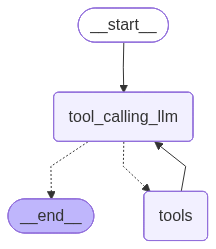

In [46]:
# Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -› tools_condition routes to tools 
    # If the latest message (result) from assistant is a not a tool call -› tools_condition routes to END
    tools_condition
)

# NOTE : Here we didnt create an edge from tools to END, but from tools to tool_calling_llm
builder.add_edge("tools","tool_calling_llm") 

#compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

See above, an edge is created from tools back to tool_calling_llm. So we give the output back to the llm to think and reason

In [ ]:
response4=graph.invoke({"messages":"Whats the latest AI news and 3 multiply by 4"})
for m in response4["messages"]:
    m.pretty_print()

================================ Human Message =================================

Whats the latest AI news and 3 multiply by 4
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x2hjb9av5)
 Call ID: x2hjb9av5
  Args:
    query: latest AI news
    time_range: day
  multiply (1grejdbxn)
 Call ID: 1grejdbxn
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=CzxqQJOswvo", "title": "Full body waifus, AI dreams, realtime AI music, open-source ...", "content": "HUGE AI NEWS: Minimax M3, Ideogram v4, Bernini, Gemma4, Nemotron 3 Ultra, & more #ai # Full body waifus, AI dreams, realtime AI music, open-source Gemini Omni:", "score": 0.9697854, "raw_content": null}, {"url": "https://www.youtube.com/watch?v=WLtCHXdHTF0", "title

### Adding memeory in agentic graph

In [ ]:
response5=graph.invoke({"messages":"My name is Khan"})
for m in response5["messages"]:
    m.pretty_print()

================================ Human Message =================================

My name is Khan
================================== Ai Message ==================================

Hello, Khan! How can I assist you today?


In [ ]:
response5=graph.invoke({"messages":"Whats my name"})
for m in response5["messages"]:
    m.pretty_print()

================================ Human Message =================================

Whats my name
================================== Ai Message ==================================

I don't have access to personal information about users, including their names. I'm an AI assistant designed to help with general knowledge, problem-solving, and providing information through the tools described above. Would you like help with something else?





Adding memory

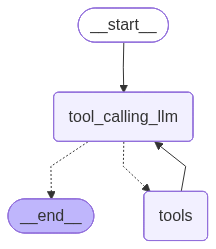

In [47]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

# NOTE : imported Memory saver. It's and in-memory check point saver
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# NOTE : Here we didnt create an edge from tools to END, but from tools to tool_calling_llm
builder.add_edge("tools","tool_calling_llm") 

graph=builder.compile(checkpointer=memory) #add : checkpointer=memory

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":"1"}} #it is needed , 
#because it will be related to one specific session

In [ ]:
response6=graph.invoke({"messages":"My name is Khan"},config=config)
response6

{'messages': [HumanMessage(content='My name is Khan', additional_kwargs={}, response_metadata={}, id='f43a6646-1b62-47d2-9044-75841f302981'),
  AIMessage(content='Hello, Khan! 😊 How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "My name is Khan." I need to respond appropriately. Let me think.\n\nFirst, I should acknowledge their name. Maybe say something like "Hello, Khan!" to be friendly.\n\nCheck if there\'s any specific tool needed here. They mentioned their name, but there\'s no question or request for information. The tools provided are for search and multiply functions. Since they didn\'t ask a question that requires a tool, I don\'t need to call any functions.\n\nJust a simple, welcoming response should suffice. Make sure it\'s polite and opens the door for further conversation. Maybe add an emoji to keep it friendly. 😊\n\nDouble-check the tools to confirm no function is needed here. Yep, no search query or math problem presented. All se

In [ ]:
response6["messages"][-1]

AIMessage(content='Hello, Khan! 😊 How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "My name is Khan." I need to respond appropriately. Let me think.\n\nFirst, I should acknowledge their name. Maybe say something like "Hello, Khan!" to be friendly.\n\nCheck if there\'s any specific tool needed here. They mentioned their name, but there\'s no question or request for information. The tools provided are for search and multiply functions. Since they didn\'t ask a question that requires a tool, I don\'t need to call any functions.\n\nJust a simple, welcoming response should suffice. Make sure it\'s polite and opens the door for further conversation. Maybe add an emoji to keep it friendly. 😊\n\nDouble-check the tools to confirm no function is needed here. Yep, no search query or math problem presented. All set.\n'}, response_metadata={'token_usage': {'completion_tokens': 176, 'prompt_tokens': 1785, 'total_tokens': 1961, 'completion_time': 0.373304751

In [ ]:
response6=graph.invoke({"messages":"Whats my name"},config=config)
response6["messages"][-1].content

"Your name is Khan. Let me know if there's anything else I can help with! 😊"

### Streaming

In [50]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver();

In [51]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]} # here write "messages" not singular "message",
    # otherise it wont show AI message

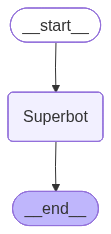

In [52]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

graph=StateGraph(State)

graph.add_node("Superbot",superbot)

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [53]:
## Invocation
config={"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi I am karan, I like to play soccer"},config=config)


{'messages': [HumanMessage(content='Hi I am karan, I like to play soccer', additional_kwargs={}, response_metadata={}, id='aa25915a-e375-4d37-a1df-f0968305ede2'),
  AIMessage(content='<think>\nOkay, Karan has introduced himself and mentioned he likes playing soccer. Let me start by acknowledging his introduction. I should respond warmly to make him feel welcome. Maybe say something like "Hi Karan! Nice to meet you!" to be friendly.\n\nSince he mentioned soccer, the next step is to engage in a conversation about it. Ask him about his experience with soccer. I can ask if he plays regularly or just for fun. Maybe also ask what position he plays if he\'s comfortable sharing. It\'s important to keep the conversation open-ended so he can elaborate. \n\nI should avoid making assumptions. For example, I don\'t know if he\'s a professional player or just plays casually, so I should ask questions that allow him to explain his level of involvement. Also, maybe ask what he enjoys most about the ga

### Streaming techniques
Methods: .stream() and astream()
- these methods are sync and async methods for streaming back results

Additional Parameters in streaming mode for graph state
- **values** : this streams the full state of the graph after each node is called -> i.e : it appends the message to the previous message
- **updates** : this streams updates to the state of the graph after each node is called. -> only prints the message of the current node.

In [54]:
# create a thread
config={"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({'messages':"Hi I am karan, I like to play soccer"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="<think>\nOkay, the user is Karan and he likes to play soccer. I need to respond appropriately. Let me start by greeting him and acknowledging his interest in soccer. Maybe ask him a question to keep the conversation going. I should keep it friendly and open-ended. Let me think of a few possibilities. What position does he play? How long has he been playing? Does he play on a team? I should pick one of these to ask. Also, maybe mention something about soccer to show I'm interested. Maybe talk about the excitement of the game. Alright, putting it all together.\n</think>\n\nHi Karan! That’s awesome—soccer is such a thrilling sport to play and watch! 🏆 What position do you usually play? I’d love to hear more about how you started playing or what you enjoy most about the game!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 174, 'prompt_tokens': 19, 'total_tokens': 193, 'completion_time': 0.401301366, 'completion_

when you use **values** , human message gets appended

In [ ]:
for chunk in graph_builder.stream({'messages':"Hi I am karan, I like to play soccer"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi I am karan, I like to play soccer', additional_kwargs={}, response_metadata={}, id='611bdaf6-0dd1-49ed-9768-b9504f1eb729'), AIMessage(content="<think>\nOkay, the user is Karan and he likes to play soccer. I need to respond appropriately. Let me start by greeting him and acknowledging his interest in soccer. Maybe ask him a question to keep the conversation going. I should keep it friendly and open-ended. Let me think of a few possibilities. What position does he play? How long has he been playing? Does he play on a team? I should pick one of these to ask. Also, maybe mention something about soccer to show I'm interested. Maybe talk about the excitement of the game. Alright, putting it all together.\n</think>\n\nHi Karan! That’s awesome—soccer is such a thrilling sport to play and watch! 🏆 What position do you usually play? I’d love to hear more about how you started playing or what you enjoy most about the game!", additional_kwargs={}, response_me

Another example
1. Here first i write : Hi , my name is Rithik. Here i used ***updates***
2. then i will write : I like to play soccer. Here i used ***values***

2nd one will get appended to first

In [57]:
# create a thread
config={"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({'messages':"Hi , my name is Rithik."},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced himself as Rithik. I should acknowledge his introduction and ask how I can assist him. Keep it friendly and open-ended. Maybe mention being helpful with any questions or tasks. Keep the response simple and welcoming.\n</think>\n\nHi Rithik! Nice to meet you! How can I assist you today? Whether you have questions, need help with a task, or just want to chat, I'm here for you. 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 17, 'total_tokens': 112, 'completion_time': 0.220628534, 'completion_tokens_details': None, 'prompt_time': 0.001444771, 'prompt_tokens_details': None, 'queue_time': 0.160249938, 'total_time': 0.222073305}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed159-fde3-7503-972d-b5cc72f94094-0', tool_call

In [58]:
for chunk in graph_builder.stream({'messages':"I like to play soccer"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi , my name is Rithik.', additional_kwargs={}, response_metadata={}, id='4940108e-3182-4c1e-83a6-18f53915e35d'), AIMessage(content="<think>\nOkay, the user introduced himself as Rithik. I should acknowledge his introduction and ask how I can assist him. Keep it friendly and open-ended. Maybe mention being helpful with any questions or tasks. Keep the response simple and welcoming.\n</think>\n\nHi Rithik! Nice to meet you! How can I assist you today? Whether you have questions, need help with a task, or just want to chat, I'm here for you. 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 17, 'total_tokens': 112, 'completion_time': 0.220628534, 'completion_tokens_details': None, 'prompt_time': 0.001444771, 'prompt_tokens_details': None, 'queue_time': 0.160249938, 'total_time': 0.222073305}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_r

USING astream
It gives more detailed info, useful in debugging.

In [59]:
config={"configurable":{"thread_id":"5"}}

async for event in graph_builder.astream_events({'messages':"Hi , my name is Rithik and I like to play cricket"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi , my name is Rithik and I like to play cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ed15e-adf4-7992-a4b9-816459361650', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi , my name is Rithik and I like to play cricket', additional_kwargs={}, response_metadata={}, id='03bc0a12-0e8c-43c0-abab-affbf4751e0a')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019ed15e-ae00-7181-b61b-f189e484fcd3', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:d2632523-706d-0295-c55d-8b9cd830da32'}, 'parent_ids': ['019ed15e-adf4-7992-a4b9-816459361650']}
{'event': 'on_chat_model_start', 'data': {'input': {'messag